**Import Some Dependencies**

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

**Preprocess The Data**

In [2]:
goldData = pd.read_csv('GoldPriceData.csv')

In [3]:
goldData.head()

,Date,Open,High,Low,Close,WAP,No. of Shares,No. of Trades,Total Turnover,Deliverable Quantity,% Deli. Qty to Traded Qty,Spread H-L,Spread C-O
0,2017-02-06,0.79,0.79,0.76,0.76,0.79,7430.0,7.0,5848.0,7430.0,100.0,0.03,-0.03
1,2017-02-03,0.79,0.79,0.79,0.79,0.79,310.0,4.0,244.0,310.0,100.0,0.00,0.00
2,2017-02-02,0.83,0.83,0.83,0.83,0.83,75.0,1.0,62.0,75.0,100.0,0.00,0.00
3,2017-01-31,0.87,0.87,0.87,0.87,0.87,1050.0,2.0,913.0,1050.0,100.0,0.00,0.00
4,2017-01-25,0.91,0.91,0.91,0.91,0.91,400.0,1.0,364.0,400.0,100.0,0.00,0.00


In [4]:
goldData.shape

(1660, 13)

In [5]:
goldData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1660 entries, 0 to 1659
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       1660 non-null   object 
 1   Open                       1660 non-null   float64
 2   High                       1660 non-null   float64
 3   Low                        1660 non-null   float64
 4   Close                      1660 non-null   float64
 5   WAP                        1660 non-null   float64
 6   No. of Shares              1660 non-null   float64
 7   No. of Trades              1660 non-null   float64
 8   Total Turnover             1660 non-null   float64
 9   Deliverable Quantity       1660 non-null   float64
 10  % Deli. Qty to Traded Qty  1660 non-null   float64
 11  Spread H-L                 1660 non-null   float64
 12  Spread C-O                 1660 non-null   float64
dtypes: float64(12), object(1)
memory usage: 168.7+ K

In [6]:
goldData.describe()

,Open,High,Low,Close,WAP,No. of Shares,No. of Trades,Total Turnover,Deliverable Quantity,% Deli. Qty to Traded Qty,Spread H-L,Spread C-O
count,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1.660000e+03,1660.000000,1660.000000,1660.000000,1660.000000
mean,11.834367,12.174048,11.221578,11.673934,11.688802,101330.338554,122.983735,1.664520e+06,75754.484337,88.678651,0.952470,-0.160434
std,17.169590,17.704607,16.143363,16.837100,16.920058,140560.465729,138.844766,2.938726e+06,96646.348605,16.648158,1.960071,1.342787
min,0.500000,0.520000,0.500000,0.520000,0.000000,1.000000,1.000000,0.000000e+00,1.000000,4.760000,0.000000,-17.150000
25%,1.350000,1.380000,1.320000,1.350000,1.336219,4393.250000,14.000000,7.159500e+03,4300.000000,78.932500,0.040000,-0.150000
50%,5.255000,5.380000,4.950000,5.085000,5.119729,33871.000000,72.500000,1.086300e+05,31095.000000,100.000000,0.180000,0.000000
75%,11.392500,11.940000,11.250000,11.377500,11.451724,153416.750000,185.250000,2.057775e+06,122723.000000,100.000000,0.890000,0.030000
max,84.950000,84.950000,71.500000,74.550000,74.972394,849341.000000,752.000000,2.383048e+07,631381.000000,100.000000,23.300000,14.000000


In [7]:
goldData.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
WAP,0
No. of Shares,0
No. of Trades,0
Total Turnover,0
Deliverable Quantity,0


**Train and Test Split**

In [9]:
X = goldData.drop(['Date','Close'],axis=1)
Y = goldData['Close']

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

*Normalize the Data

In [16]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

**Evaluation**

In [21]:
Y_pred1 = model.predict(X_test)
Y_pred2 = model.predict(X_train)

In [22]:
print(Y_pred1)
print(Y_pred2)

[35.9   0.86  0.83  8.24  2.   13.6   8.48  1.44 20.45  1.66  8.27 52.75
  6.03 16.    1.29 50.35 14.01 38.65 22.65 11.35  8.91 38.85 14.75  8.82
 13.41  1.29  2.03 13.9   9.26 10.2   7.14 71.95  7.97  1.26  7.55 49.15
  1.17  1.72  6.41  8.22 40.85  1.71  1.19  1.63  2.09  1.31  1.21  2.19
  2.06  0.9   0.81  1.33 60.4   0.73 13.8   1.28 32.8   1.34  1.44  0.54
  1.27 64.6   1.81 14.82  7.   30.65  5.49  5.26  8.44  8.53  8.25  9.23
 34.   16.05  0.63  7.26 49.6  53.75  6.88  1.64  0.6   8.23 11.76  2.16
 52.4   1.12 13.96  9.37  8.45  6.89  0.97 34.05  2.7   1.27  1.26  7.68
  5.61  8.36  2.38  1.05 65.7  25.95  1.35  0.73  5.01  0.91  2.04 33.85
  8.45  1.74 67.9   0.89  1.68 66.2  21.    1.95  8.3   9.37  1.08  2.2
  2.04  7.15  0.78  0.72  8.78  1.94  6.16  0.73  1.33  1.64 60.    7.31
  1.2   1.69  2.28  8.76  1.23  0.87  7.86  0.91  1.34  1.35  0.84  0.84
  0.77 13.77 39.05  1.2   1.55  1.89  1.21  2.95  9.47 21.05  1.33  2.19
  7.17 11.91 21.25  5.04  1.26 41.25 12.94 16.25  1.

In [25]:
mse = mean_squared_error(Y_test, Y_pred1)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred1)

In [28]:
print(f"{mse:.2f}")
print(f"{rmse:.2f}")
print(f"{r2:.2f}")

0.00
0.00
1.00


**Visualize The Data**

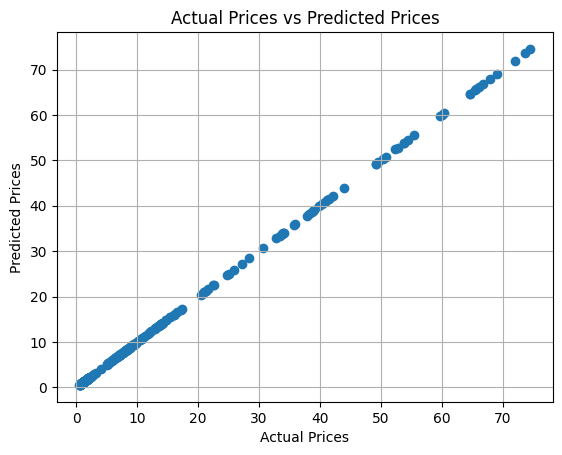

In [30]:
plt.scatter(Y_test, Y_pred1)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.grid(True)
plt.show()

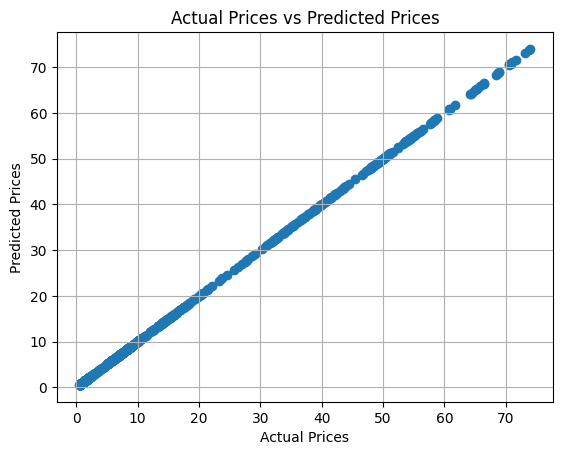

In [31]:
plt.scatter(Y_train, Y_pred2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.grid(True)
plt.show()

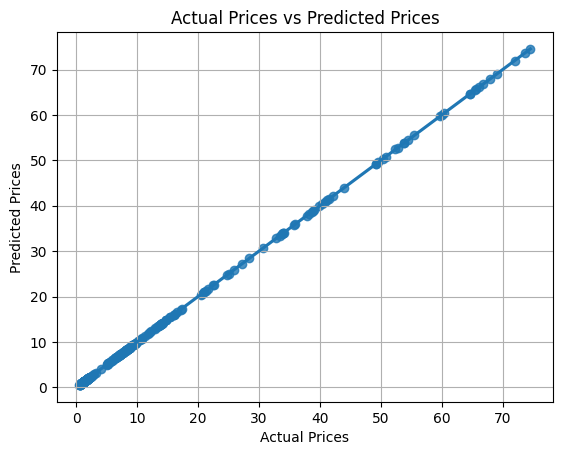

In [37]:
sns.regplot(x=Y_test, y=Y_pred1, ci=None)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.grid(True)
plt.show()

In [38]:
from sklearn.ensemble import RandomForestRegressor

In [39]:
RandomForestRegressorModel = RandomForestRegressor(n_estimators=100)
RandomForestRegressorModel.fit(X_train, Y_train)

RandomForestRegressor()

In [40]:
Y_pred1 = RandomForestRegressorModel.predict(X_test)
Y_pred2 = RandomForestRegressorModel.predict(X_train)

In [44]:
mse = mean_squared_error(Y_test, Y_pred1)
r2 = r2_score(Y_test, Y_pred1)
r2_rf = RandomForestRegressorModel.score(X_test, Y_test)

In [45]:
print(f"{mse:.2f}")
print(f"{r2:.2f}")
print(f"{r2_rf:.2f}")

0.30
1.00
1.00


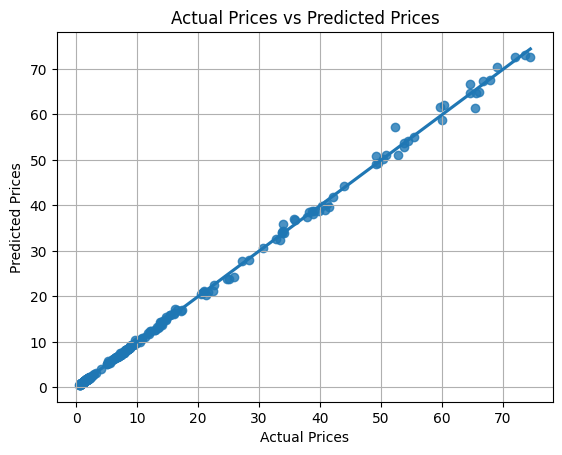

In [46]:
sns.regplot(x=Y_test, y=Y_pred1, ci=None)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.grid(True)
plt.show()